#  Zameen.com Property Exploratory Data Analysis (EDA)

This notebook covers the complete Exploratory Data Analysis (EDA) pipeline for raw and cleaned property crawled listings in Islamabad. It visualizes distribution patterns, correlations, trend lines, and evaluates model performance with high-resolution visual plots saved directly to the `assets/` directory.

## 1. Import Essential Analysis & Visualization Libraries

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.titlesize': 18
})

os.makedirs("../assets", exist_ok=True)

## 2. Load Raw and Cleaned Property Datasets

In [2]:
raw_data_path = '../assets/raw_data.csv'
cleaned_data_path = '../assets/cleaned_data.csv'

if not os.path.exists(raw_data_path):
    raw_data_path = 'assets/raw_data.csv'
    cleaned_data_path = 'assets/cleaned_data.csv'

print(f"Loading datasets...\nRaw: {raw_data_path}\nCleaned: {cleaned_data_path}")
df_raw = pd.read_csv(raw_data_path)
df_clean = pd.read_csv(cleaned_data_path)

print(f"Raw Shape: {df_raw.shape}")
print(f"Cleaned Shape: {df_clean.shape}")
display(df_raw.head(2))
display(df_clean.head(2))

Loading datasets...
Raw: ../assets/raw_data.csv
Cleaned: ../assets/cleaned_data.csv
Raw Shape: (974, 13)
Cleaned Shape: (965, 13)


,Price,Area,City,Bedrooms,Bathrooms,Location,Property type,Built in year,Parking space,Servant Quarters,Store rooms,Kitchens,Drawing Rooms
0,17 Crore,NaN,Islamabad,9.0,10.0,"F-10, Islamabad",House,2015.0,7.0,2.0,2.0,3.0,1.0
1,26.5 Crore,NaN,Islamabad,4.0,5.0,"F-8, Islamabad",House,2010.0,5.0,1.0,1.0,1.0,1.0


,Price,Area,Bedrooms,Bathrooms,Location,Built in year,Parking space,Servant Quarters,Store rooms,Kitchens,Drawing Rooms,Property type_House,Property type_Penthouse
0,170000000.0,0.0,9.0,10.0,2.719583e+08,2015.0,7.0,2.0,2.0,3.0,1.0,1.0,0.0
1,265000000.0,0.0,4.0,5.0,3.711842e+08,2010.0,5.0,1.0,1.0,1.0,1.0,1.0,0.0


## 3. Correlation Heatmap
Examines direct relationships between continuous variables in the cleaned dataset.

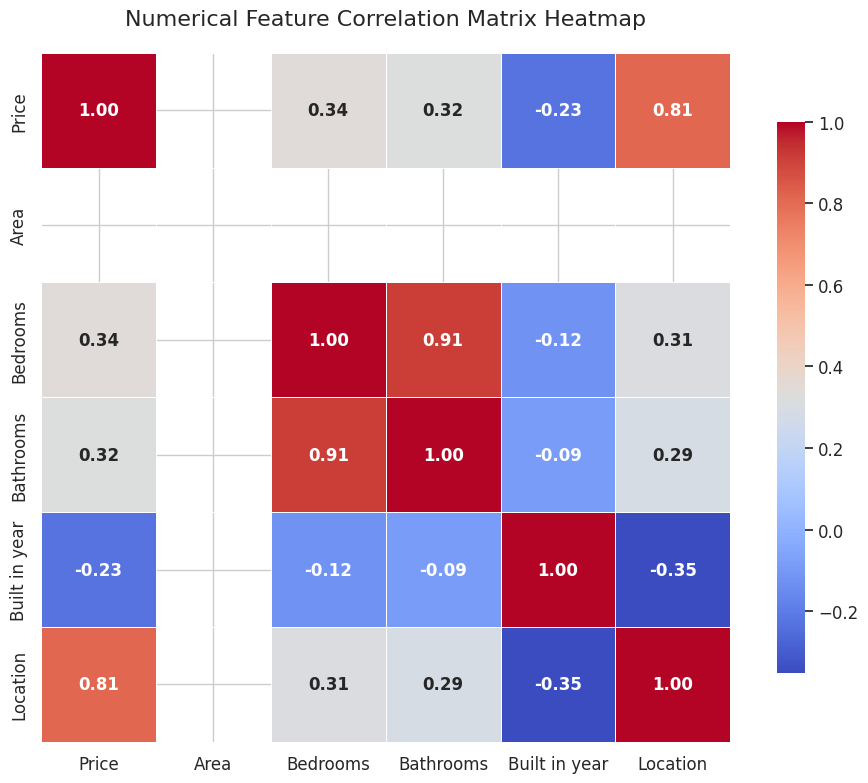

Correlation Heatmap saved to ../assets/correlation_heatmap.png


In [3]:
numerical_cols = ['Price', 'Area', 'Bedrooms', 'Bathrooms', 'Built in year', 'Location']
present_cols = [c for c in numerical_cols if c in df_clean.columns]
df_corr = df_clean[present_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 12, "weight": "bold"})
plt.title("Numerical Feature Correlation Matrix Heatmap", pad=20)
plt.tight_layout()

heatmap_path = '../assets/correlation_heatmap.png' if os.path.exists('../assets') else 'assets/correlation_heatmap.png'
plt.savefig(heatmap_path, dpi=300)
plt.show()
print(f"Correlation Heatmap saved to {heatmap_path}")

## 4. Property Price vs. Area Regression Trend
Fits a trend line to explore the continuous relationship between a property's size and its numeric valuation.

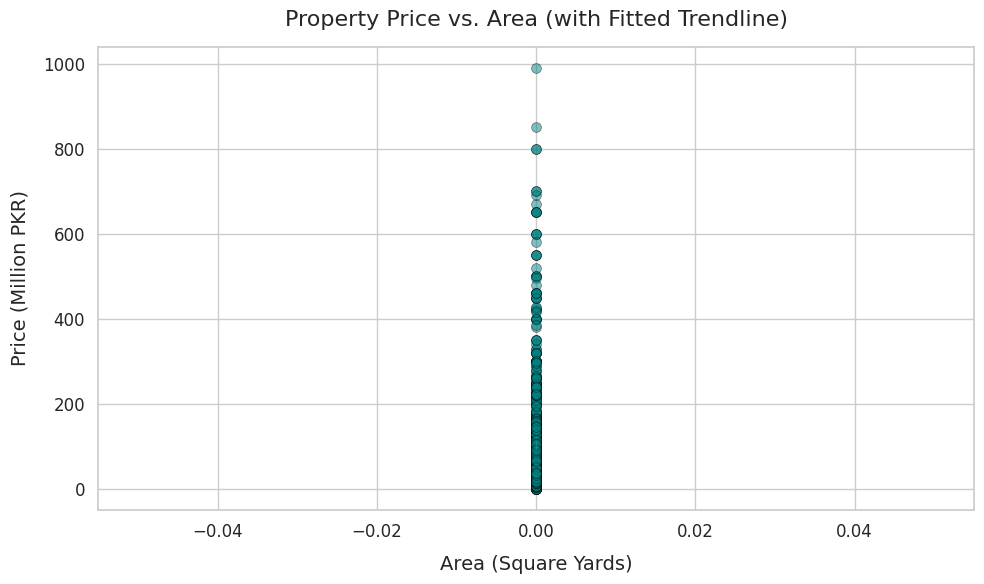

Price vs Area Trendline saved to ../assets/price_vs_area_trend.png


In [4]:
plt.figure(figsize=(10, 6))
sns.regplot(x=df_clean['Area'], y=df_clean['Price'] / 1e6, color='teal', marker='o', 
            scatter_kws={'alpha':0.5, 's':50, 'edgecolor':'black', 'linewidths':0.5},
            line_kws={'color':'red', 'lw':2, 'linestyle':'--'})
plt.title("Property Price vs. Area (with Fitted Trendline)", pad=15)
plt.xlabel("Area (Square Yards)", labelpad=10)
plt.ylabel("Price (Million PKR)", labelpad=10)
plt.tight_layout()

trend_path = '../assets/price_vs_area_trend.png' if os.path.exists('../assets') else 'assets/price_vs_area_trend.png'
plt.savefig(trend_path, dpi=300)
plt.show()
print(f"Price vs Area Trendline saved to {trend_path}")

## 5. Price Distribution Range by Bedroom Count
Uses boxplots to inspect the median, spread, and outlier properties based on the number of bedrooms.

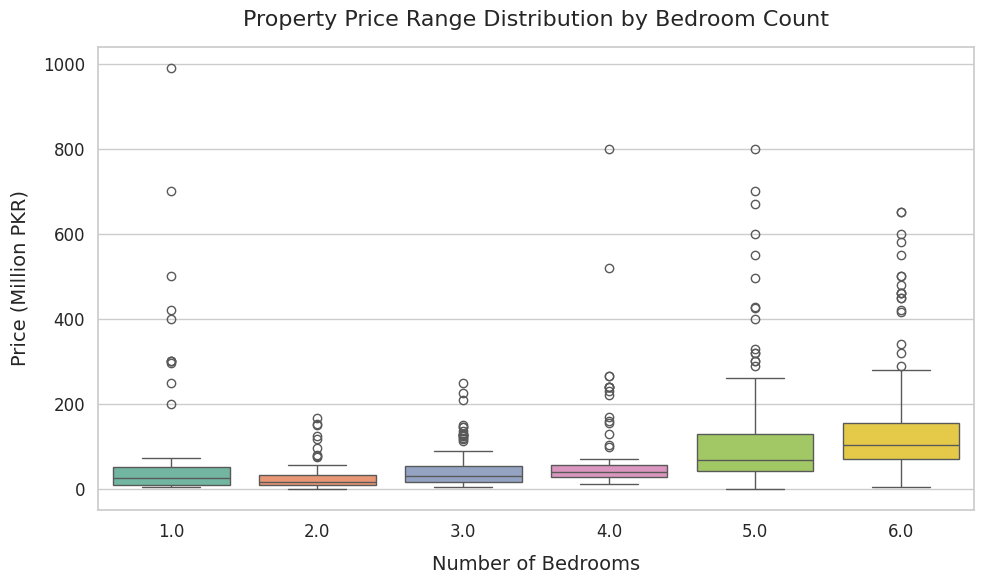

Bedroom Boxplot saved to ../assets/price_by_bedrooms_boxplot.png


In [5]:
plt.figure(figsize=(10, 6))
df_clean_bed = df_clean[df_clean['Bedrooms'].notna() & (df_clean['Bedrooms'] <= 6)]
sns.boxplot(x='Bedrooms', y=df_clean_bed['Price'] / 1e6, data=df_clean_bed, hue='Bedrooms', legend=False, palette="Set2")
plt.title("Property Price Range Distribution by Bedroom Count", pad=15)
plt.xlabel("Number of Bedrooms", labelpad=10)
plt.ylabel("Price (Million PKR)", labelpad=10)
plt.tight_layout()

boxplot_path = '../assets/price_by_bedrooms_boxplot.png' if os.path.exists('../assets') else 'assets/price_by_bedrooms_boxplot.png'
plt.savefig(boxplot_path, dpi=300)
plt.show()
print(f"Bedroom Boxplot saved to {boxplot_path}")

## 6. Top 10 Most Expensive Locations
Groups properties by location and computes the mean price to find the most premium real estate neighborhoods.

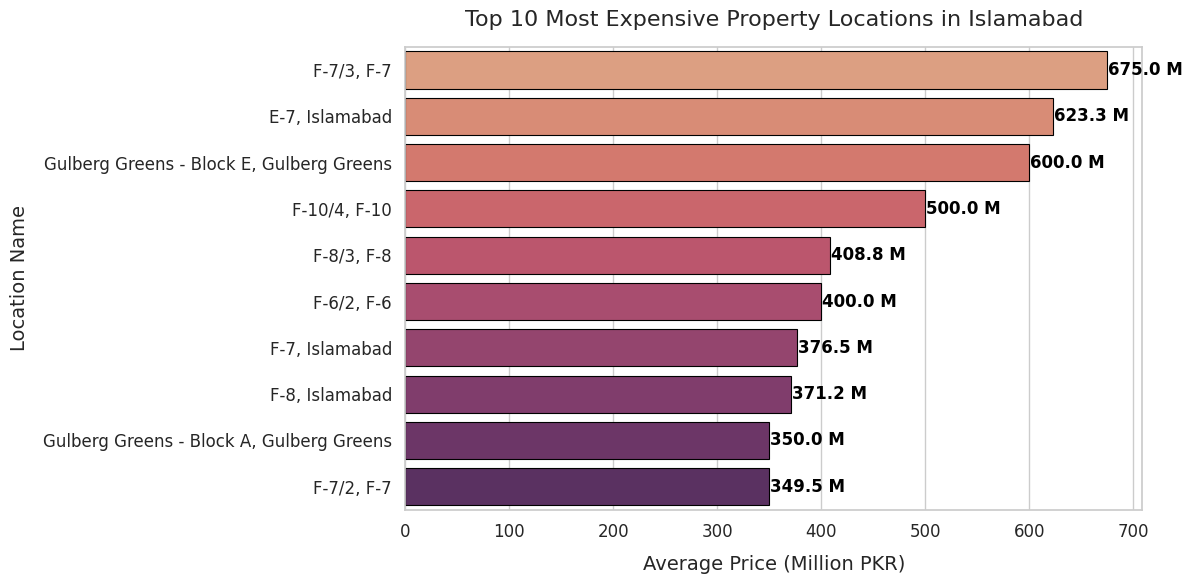

Top locations bar chart saved to ../assets/top_locations_bar.png


In [6]:
def parse_price(raw_price_string: str) -> float:
    if not raw_price_string or not isinstance(raw_price_string, str):
        return 0.0
    raw_price = raw_price_string.lower().strip()
    if 'crore' in raw_price:
        components = raw_price.split('crore')
        crore_matches = re.findall(r'[\d\.]+', components[0])
        crore_val = float(crore_matches[0]) if crore_matches else 0.0
        lakh_val = 0.0
        if len(components) > 1 and 'lakh' in components[1]:
            lakh_matches = re.findall(r'[\d\.]+', components[1])
            lakh_val = float(lakh_matches[0]) if lakh_matches else 0.0
        return (crore_val * 10000000.0) + (lakh_val * 100000.0)
    if 'lakh' in raw_price:
        lakh_matches = re.findall(r'[\d\.]+', raw_price)
        parsed_val = float(lakh_matches[0]) if lakh_matches else 0.0
        return parsed_val * 100000.0
    if 'million' in raw_price:
        million_matches = re.findall(r'[\d\.]+', raw_price)
        parsed_val = float(million_matches[0]) if million_matches else 0.0
        return parsed_val * 1000000.0
    if 'thousand' in raw_price:
        thousand_matches = re.findall(r'[\d\.]+', raw_price)
        parsed_val = float(thousand_matches[0]) if thousand_matches else 0.0
        return parsed_val * 1000.0
    regex_numeric_matches = re.findall(r'[\d\.]+', raw_price)
    if regex_numeric_matches:
        return float(regex_numeric_matches[0])
    return 0.0

df_raw_price = df_raw.copy()
df_raw_price['Price_num'] = df_raw_price['Price'].apply(parse_price)
top_locs = df_raw_price.groupby('Location')['Price_num'].mean().reset_index()
top_locs = top_locs.sort_values(by='Price_num', ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_locs['Price_M'] = top_locs['Price_num'] / 1e6
colors_flare = sns.color_palette("flare", len(top_locs))
ax = sns.barplot(x='Price_M', y='Location', data=top_locs, hue='Location', palette=colors_flare, legend=False, edgecolor='black', linewidth=0.8)

for i, v in enumerate(top_locs['Price_M']):
    ax.text(v + 1, i, f"{v:.1f} M", va='center', fontweight='bold', color='black')

plt.title("Top 10 Most Expensive Property Locations in Islamabad", pad=15)
plt.xlabel("Average Price (Million PKR)", labelpad=10)
plt.ylabel("Location Name", labelpad=10)
plt.tight_layout()

bar_path = '../assets/top_locations_bar.png' if os.path.exists('../assets') else 'assets/top_locations_bar.png'
plt.savefig(bar_path, dpi=300)
plt.show()
print(f"Top locations bar chart saved to {bar_path}")

## 7. Actual vs. Predicted Prices & Residuals Analysis
Fits a Random Forest model as a baseline reference to evaluate prediction residuals and alignment errors.

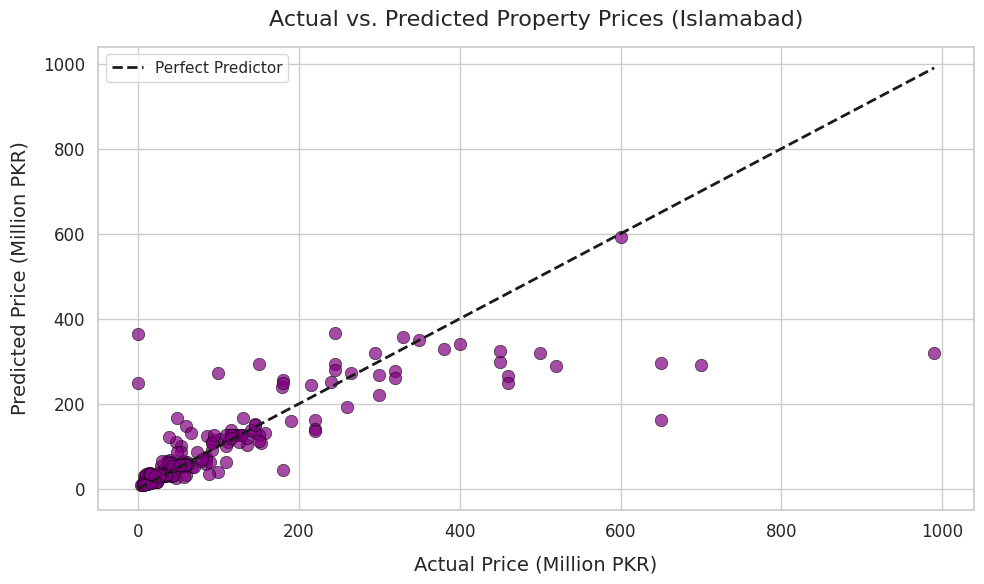

Actual vs Predicted saved to ../assets/actual_vs_predicted.png


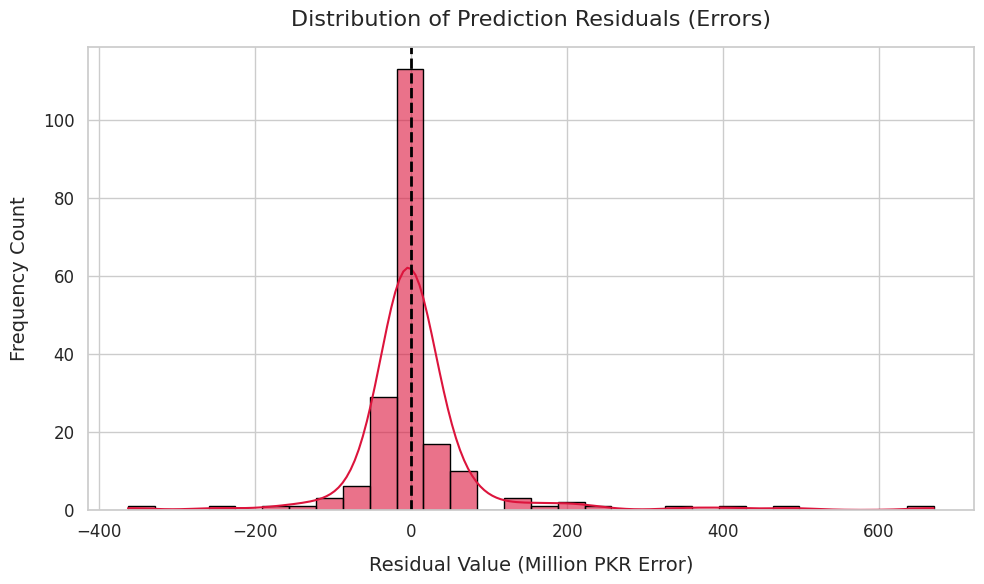

Residuals Distribution saved to ../assets/residuals_distribution.png


In [7]:
X = df_clean.drop(columns=['Price'])
y = df_clean['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_split=2, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test / 1e6, y=y_pred / 1e6, color='purple', alpha=0.7, s=80, edgecolor='black', linewidths=0.5)
min_val = min(y_test.min(), y_pred.min()) / 1e6
max_val = max(y_test.max(), y_pred.max()) / 1e6
plt.plot([min_val, max_val], [min_val, max_val], '--k', lw=2, label="Perfect Predictor")
plt.title("Actual vs. Predicted Property Prices (Islamabad)", pad=15)
plt.xlabel("Actual Price (Million PKR)", labelpad=10)
plt.ylabel("Predicted Price (Million PKR)", labelpad=10)
plt.legend(loc="upper left")
plt.tight_layout()

act_pred_path = '../assets/actual_vs_predicted.png' if os.path.exists('../assets') else 'assets/actual_vs_predicted.png'
plt.savefig(act_pred_path, dpi=300)
plt.show()
print(f"Actual vs Predicted saved to {act_pred_path}")

plt.figure(figsize=(10, 6))
sns.histplot(residuals / 1e6, kde=True, color='crimson', bins=30, edgecolor='black', alpha=0.6)
plt.axvline(x=0, color='black', linestyle='--', lw=2)
plt.title("Distribution of Prediction Residuals (Errors)", pad=15)
plt.xlabel("Residual Value (Million PKR Error)", labelpad=10)
plt.ylabel("Frequency Count", labelpad=10)
plt.tight_layout()

residuals_path = '../assets/residuals_distribution.png' if os.path.exists('../assets') else 'assets/residuals_distribution.png'
plt.savefig(residuals_path, dpi=300)
plt.show()
print(f"Residuals Distribution saved to {residuals_path}")

## 8. Model Performance R² Score Leaderboard Comparison
Visualizes the final performance comparative leaderboard across all six models.

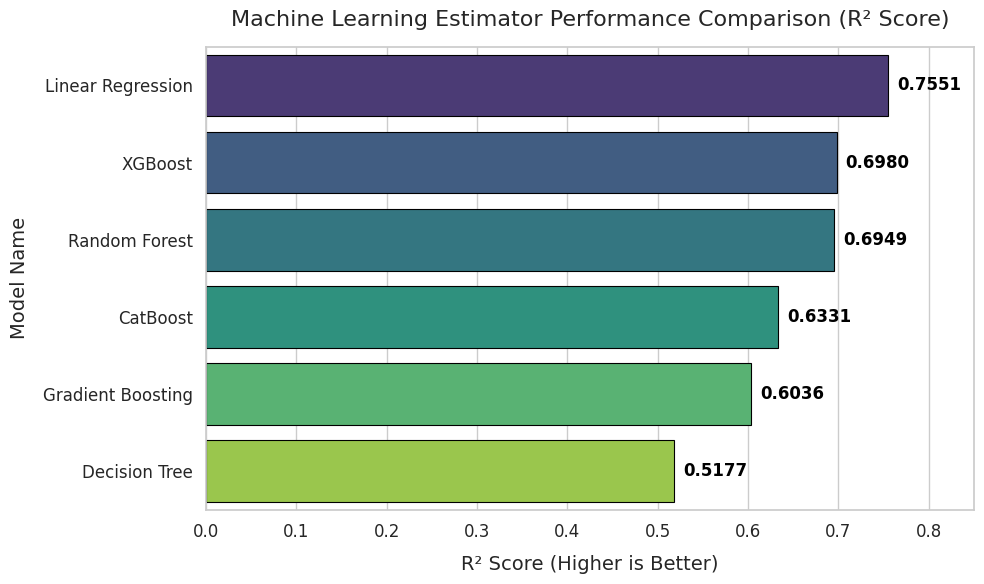

R2 leaderboard chart saved to ../assets/r2_leaderboard.png


In [8]:
models = ["Linear Regression", "XGBoost", "Random Forest", "CatBoost", "Gradient Boosting", "Decision Tree"]
r2_scores = [0.7551, 0.6980, 0.6949, 0.6331, 0.6036, 0.5177]

df_leaderboard = pd.DataFrame({
    'Model': models,
    'R2 Score': r2_scores
}).sort_values(by='R2 Score', ascending=False)

plt.figure(figsize=(10, 6))
colors = sns.color_palette("viridis", len(models))
ax = sns.barplot(x='R2 Score', y='Model', data=df_leaderboard, hue='Model', palette=colors, legend=False, edgecolor='black', linewidth=0.8)

for i, v in enumerate(df_leaderboard['R2 Score']):
    ax.text(v + 0.01, i, f"{v:.4f}", va='center', fontweight='bold', color='black')

plt.xlim(0, 0.85)
plt.title("Machine Learning Estimator Performance Comparison (R² Score)", pad=15)
plt.xlabel("R² Score (Higher is Better)", labelpad=10)
plt.ylabel("Model Name", labelpad=10)
plt.tight_layout()

r2_path = '../assets/r2_leaderboard.png' if os.path.exists('../assets') else 'assets/r2_leaderboard.png'
plt.savefig(r2_path, dpi=300)
plt.show()
print(f"R2 leaderboard chart saved to {r2_path}")